平均绝对百分比误差为: 2.99%
实际值在预测上下限区间的概率为: 92.11%


C:\Users\Xdream\AppData\Roaming\Python\Python311\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__periodicity is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Xdream\AppData\Roaming\Python\Python311\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


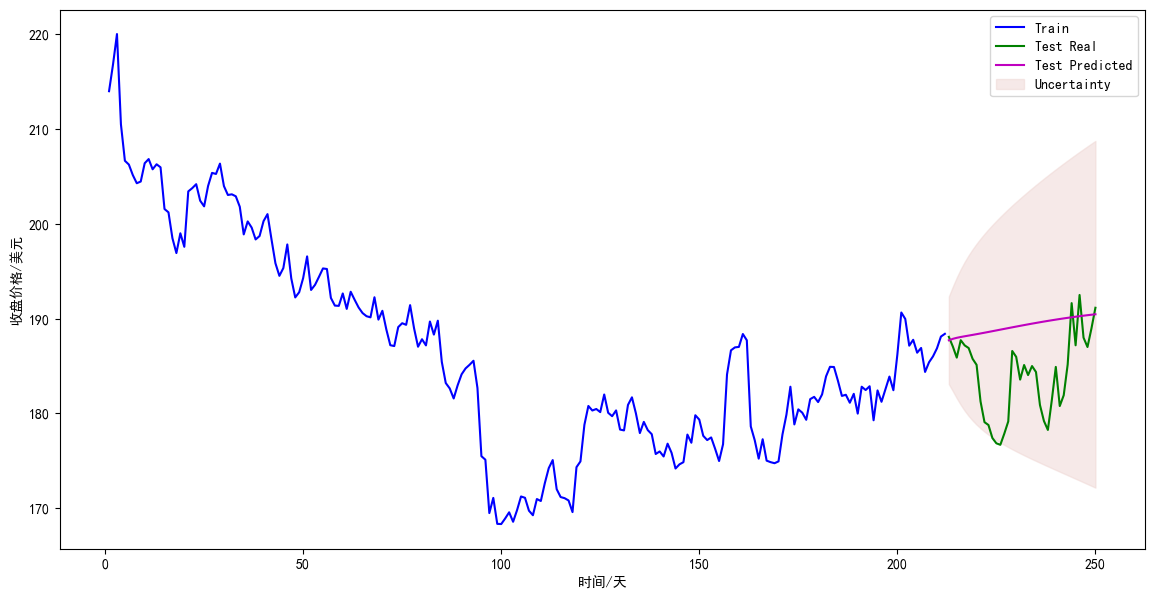

In [292]:
import pandas as pd
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel,RBF,RationalQuadratic,ExpSineSquared
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 读取数据
data1 = pd.read_csv('VRSN.csv', parse_dates=['Date'], index_col='Date')
# 检查数据是否已经是按日期升序排列
if not data1.index.is_monotonic_increasing:
    # 如果不是升序排列，则进行排序
    data1 = data1.sort_index(ascending=True)
# 去除 'Close/Last' 列中的货币符号并转换为浮点数
data1['Close/Last'] = data1['Close/Last'].str.replace(r'[^\d.]', '', regex=True).astype(float)
stock1 = data1['Close/Last'].values 

# 创建时间索引
time_index = np.arange(1, len(stock1) + 1).reshape(-1, 1)
# 按8:2比例划分训练集和测试集
trainX, testX, trainY, testYreal = train_test_split(time_index, stock1, test_size=0.15, shuffle=False)

# 标准化数据
scaler = StandardScaler()
trainY_scaled = scaler.fit_transform(trainY.reshape(-1, 1)).ravel()

# GPR模型:Matern 和 WhiteKernel 组合
#kernel = ConstantKernel() * Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=1)

#Rational Quadratic + WhiteKernel
#kernel = ConstantKernel() * RationalQuadratic(length_scale=1.0, alpha=1.0) + WhiteKernel(noise_level=1)
#RBF * Periodic + WhiteKernel(okk)
#kernel = ConstantKernel() * RBF(length_scale=1.0) * ExpSineSquared(length_scale=1.0, periodicity=30) + WhiteKernel(noise_level=1)
#Rational Quadratic * Periodic + WhiteKernel
kernel = ConstantKernel() * RationalQuadratic(length_scale=1.0, alpha=1.0) * ExpSineSquared(length_scale=1.0, periodicity=30) + WhiteKernel(noise_level=1)
gprMdl = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=0.1, normalize_y=True)
gprMdl.fit(trainX, trainY_scaled)

# 预测
testYpd_scaled, sigma = gprMdl.predict(testX, return_std=True)
testYpd = scaler.inverse_transform(testYpd_scaled.reshape(-1, 1)).ravel()
Lower = scaler.inverse_transform((testYpd_scaled - 1.96 * sigma).reshape(-1, 1)).ravel()
Upper = scaler.inverse_transform((testYpd_scaled + 1.96 * sigma).reshape(-1, 1)).ravel()


# 计算误差
erravg = np.mean(np.abs(testYpd - testYreal) / testYreal)
print(f'平均绝对百分比误差为: {erravg:.2%}')

# 计算测试集实际值在上下限的概率
y3 = (testYreal > Lower) & (testYreal < Upper)
errarea = np.mean(y3)
print(f'实际值在预测上下限区间的概率为: {errarea:.2%}')


# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号 '-' 显示为方块的问题
# 作图
plt.figure(figsize=(14, 7))
plt.plot(trainX, trainY, 'b', label='Train')
plt.plot(testX, testYreal, 'g', label='Test Real')
plt.plot(testX, testYpd, 'm', label='Test Predicted')
plt.fill_between(testX.ravel(), Lower, Upper, color=[0.93333, 0.83529, 0.82353], alpha=0.5, label='Uncertainty')
plt.xlabel('时间/天')
plt.ylabel('收盘价格/美元')
plt.legend()
plt.show()

In [293]:
trainY

array([213.99, 216.81, 220.02, 210.49, 206.65, 206.25, 205.14, 204.28,
       204.46, 206.39, 206.83, 205.75, 206.28, 205.96, 201.56, 201.21,
       198.48, 196.91, 199.  , 197.57, 203.42, 203.76, 204.18, 202.44,
       201.84, 203.99, 205.37, 205.26, 206.35, 203.98, 203.04, 203.11,
       202.9 , 201.8 , 198.88, 200.25, 199.6 , 198.35, 198.71, 200.28,
       201.02, 198.38, 195.84, 194.51, 195.33, 197.82, 194.24, 192.23,
       192.78, 194.27, 196.56, 193.02, 193.56, 194.41, 195.29, 195.23,
       192.18, 191.37, 191.34, 192.65, 191.02, 192.83, 191.98, 191.17,
       190.58, 190.25, 190.13, 192.25, 189.89, 190.82, 188.85, 187.19,
       187.1 , 189.1 , 189.51, 189.34, 191.42, 188.97, 187.03, 187.82,
       187.17, 189.69, 188.31, 189.78, 185.43, 183.2 , 182.63, 181.57,
       182.96, 184.12, 184.74, 185.12, 185.55, 182.68, 175.48, 175.11,
       169.48, 171.08, 168.34, 168.32, 168.91, 169.56, 168.56, 169.79,
       171.23, 171.09, 169.73, 169.25, 170.96, 170.75, 172.62, 174.22,
      

In [294]:
data1

,Close/Last,Volume,Open,High,Low
Date,,,,,
2023-12-11,213.99,468490,$212.69,$214.27,$212.52
2023-12-12,216.81,535343,$214.85,$217.12,$213.835
2023-12-13,220.02,438348,$217.28,$220.51,$217.005
2023-12-14,210.49,835864,$220.40,$220.91,$210.45
2023-12-15,206.65,1688923,$208.75,$210.02,$204.82
...,...,...,...,...,...
2024-12-02,192.49,1041303,$187.00,$192.85,$185.645
2024-12-03,187.99,729937,$192.06,$192.48,$187.82
2024-12-04,187.00,505787,$188.16,$189.26,$185.44


In [295]:
#testYpd

In [296]:
# 回测部分
def backtest(predictions, actuals, initial_balance=10000):
    balance = initial_balance
    position = 0  # 0 表示空仓，1 表示持仓
    daily_returns = []
    
    for i in range(len(predictions)):
        if predictions[i] > actuals[i]:  # 预测价格上涨，买入
            if position == 0:
                position = 1
                buy_price = actuals[i]
        elif predictions[i] < actuals[i]:  # 预测价格下跌，卖出
            if position == 1:
                position = 0
                sell_price = actuals[i]
                profit = sell_price - buy_price
                balance += profit
                daily_returns.append(profit / buy_price)
            else:
                daily_returns.append(0)
        else:
            daily_returns.append(0)
    
    # 计算累计收益
    cumulative_returns = np.cumsum(daily_returns)
    
    # 计算最大回撤
    max_drawdown = np.max(np.maximum.accumulate(cumulative_returns) - cumulative_returns)
    
    # 计算夏普比率
    sharpe_ratio = np.mean(daily_returns) / np.std(daily_returns, ddof=1) * np.sqrt(252)  # 假设一年有252个交易日
    
    return {
        'cumulative_returns': cumulative_returns,
        'max_drawdown': max_drawdown,
        'sharpe_ratio': sharpe_ratio,
        'final_balance': balance
    }

# 进行回测
backtest_results = backtest(testYpd, testYreal)

# 打印回测结果
print(f"累计收益: {backtest_results['cumulative_returns'][-1]:.2f}")
print(f"最大回撤: {backtest_results['max_drawdown']:.2f}")
print(f"夏普比率: {backtest_results['sharpe_ratio']:.2f}")
print(f"最终余额: {backtest_results['final_balance']:.2f}")

累计收益: 0.07
最大回撤: 0.00
夏普比率: 21.99
最终余额: 10013.03


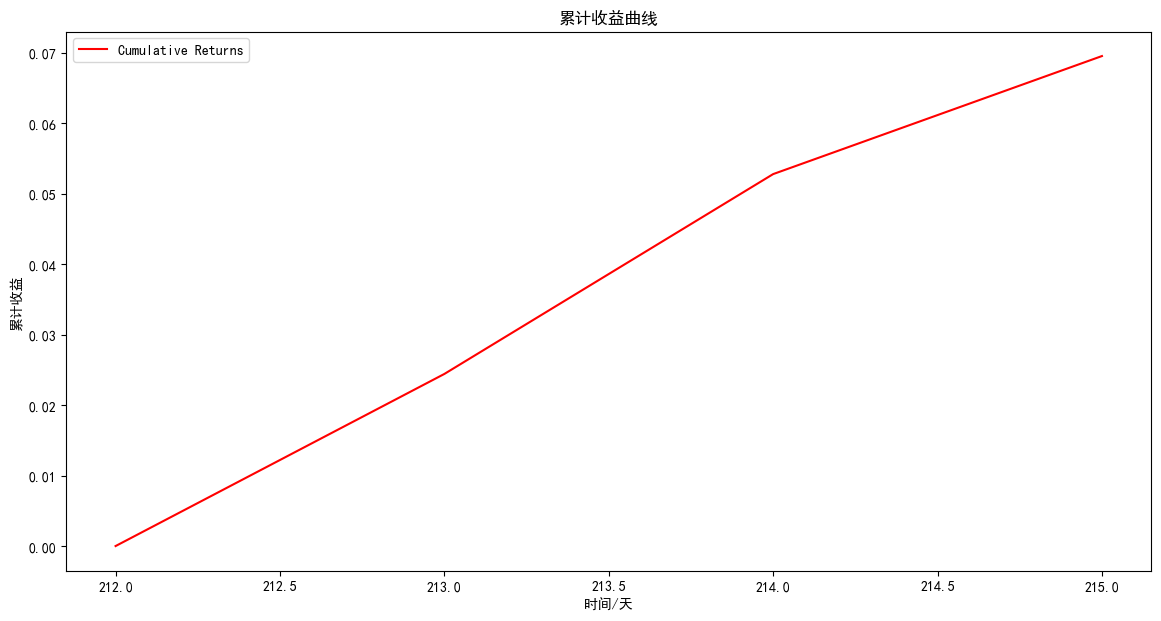

In [297]:
# 绘制累计收益曲线
plt.figure(figsize=(14, 7))
plt.plot(np.arange(len(backtest_results['cumulative_returns'])) + len(trainX), 
         backtest_results['cumulative_returns'], 'r', label='Cumulative Returns')
plt.xlabel('时间/天')
plt.ylabel('累计收益')
plt.title('累计收益曲线')
plt.legend()
plt.show()

In [298]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import empyrical as ey  # 用于计算回测指标

In [299]:
# 提取测试集的日期、开盘价和收盘价
# 使用 testX 中的日期索引来提取对应的数据
test_data = data1.loc[pd.to_datetime(testX.flatten())]
test_data['predicted_close'] = testYpd
test_data['real_close'] = testYreal

# 确保数据按日期排序
test_data = test_data.sort_index()

KeyError: "None of [DatetimeIndex(['1970-01-01 00:00:00.000000213',\n               '1970-01-01 00:00:00.000000214',\n               '1970-01-01 00:00:00.000000215',\n               '1970-01-01 00:00:00.000000216',\n               '1970-01-01 00:00:00.000000217',\n               '1970-01-01 00:00:00.000000218',\n               '1970-01-01 00:00:00.000000219',\n               '1970-01-01 00:00:00.000000220',\n               '1970-01-01 00:00:00.000000221',\n               '1970-01-01 00:00:00.000000222',\n               '1970-01-01 00:00:00.000000223',\n               '1970-01-01 00:00:00.000000224',\n               '1970-01-01 00:00:00.000000225',\n               '1970-01-01 00:00:00.000000226',\n               '1970-01-01 00:00:00.000000227',\n               '1970-01-01 00:00:00.000000228',\n               '1970-01-01 00:00:00.000000229',\n               '1970-01-01 00:00:00.000000230',\n               '1970-01-01 00:00:00.000000231',\n               '1970-01-01 00:00:00.000000232',\n

In [ ]:
def backTest(predicted_prices, real_prices, initial_cash=100000000, fee_rate=1e-4):
    """
    回测函数，基于预测的股价进行交易决策。
    
    参数:
    - predicted_prices: 预测的收盘价数组
    - real_prices: 实际的开盘价和收盘价DataFrame
    - initial_cash: 初始现金
    - fee_rate: 手续费率
    
    返回:
    - return_value: 包含资产总额、收益率等信息的DataFrame
    """
    
    # 初始化变量
    stock = [0]                     # 持仓
    cash = [initial_cash]           # 现金
    value = []                      # 资产总额
    cost = [0.0]                    # 交易成本
    
    for i in range(len(real_prices)):
        today_real = real_prices.iloc[i]
        pred_price = predicted_prices[i]
        
        if i == 0:
            amount = 0
        elif pred_price > today_real['Open']:  # 全仓买入
            money = cash[i - 1]
            price = today_real['Open']
            amount = math.floor(0.9 * money / price)  # 保留10%现金作为缓冲
            # 买入操作
            stock.append(stock[i-1] + amount)
            cash.append(money - price * amount * (1.0 + fee_rate))
            cost.append(cost[i-1] + price * amount * fee_rate)
        elif pred_price <= today_real['Open']:  # 清仓
            amount = stock[i-1]
            price = today_real['Open']
            stock.append(0)
            money = amount * price
            cash.append(money * (1.0 - fee_rate) + cash[i-1])
            cost.append(cost[i-1] + money * fee_rate)
        else:
            stock.append(stock[i-1])
            cash.append(cash[i-1])
            cost.append(cost[i-1])
        
        # 计算当天的资产总额
        value.append(cash[i] + stock[i] * today_real['Close'])
    
    # 生成资产总额数据
    return_value = pd.DataFrame({
        'value': value,
        'returns': pd.Series(value).pct_change(),
        'benchmark_returns': real_prices['Close'].pct_change().values,
        'date': real_prices.index[:len(value)]
    })
    return_value.index = return_value['date']
    
    # 画资产总额图
    plt.figure(figsize=(14, 7))
    plt.plot(return_value['value'], label='Asset Value')
    plt.title('Asset Value Over Time')
    plt.xlabel('Time')
    plt.ylabel('Value (CNY)')
    plt.legend()
    plt.show()
    
    # 画每日收益率图
    plt.figure(figsize=(14, 7))
    plt.plot(return_value['returns'], label='Strategy Returns')
    plt.plot(return_value['benchmark_returns'], label='Benchmark Returns')
    plt.title('Daily Returns')
    plt.xlabel('Time')
    plt.ylabel('Returns')
    plt.legend()
    plt.show()
    
    return return_value

def evaluation(value):
    """
    评估回测结果，计算各种绩效指标。
    
    参数:
    - value: 包含资产总额、收益率等信息的DataFrame
    
    返回:
    - bk_results: 包含各项指标的DataFrame
    """
    
    returns = value['returns'].dropna()
    benchmark = value['benchmark_returns'].dropna()
    excess_return = returns - benchmark
    
    # 用empyrical计算回测指标
    bk_results = pd.DataFrame(index=[0])
    
    # 年化收益率
    bk_results["年化收益率"] = [ey.annual_return(returns)]
    
    # 累计收益率
    bk_results["累计收益率"] = [ey.cum_returns_final(returns)]
    
    # 最大回撤
    bk_results["最大回撤"] = [ey.max_drawdown(returns)]
    
    # 夏普比率
    bk_results["夏普比率"] = [ey.sharpe_ratio(excess_return)]
    
    # 索提比率
    bk_results["索提比率"] = [ey.sortino_ratio(returns)]
    
    # αβ值
    alpha, beta = ey.alpha_beta(returns, benchmark, risk_free=0.02)
    bk_results["α"] = [alpha]
    bk_results["β"] = [beta]
    
    print("回测指标：")
    print(bk_results)
    
    return bk_results

In [ ]:
# 运行回测
backtest_results = backTest(testYpd, test_data[['Open', 'Close']], initial_cash=100000000, fee_rate=1e-4)

# 评估回测结果
evaluation_results = evaluation(backtest_results)